# Часть 1. Множественное выравнивание

Я выбрал Глицеральдегид-3-фосфатдегидрогеназу для 4 видов:
- Homo sapiens (Человек разумный)
- Danio rerio (Зебраданио)
- Mus musculus (Мышь домовая)
- Bos taurus (Бык домашний)

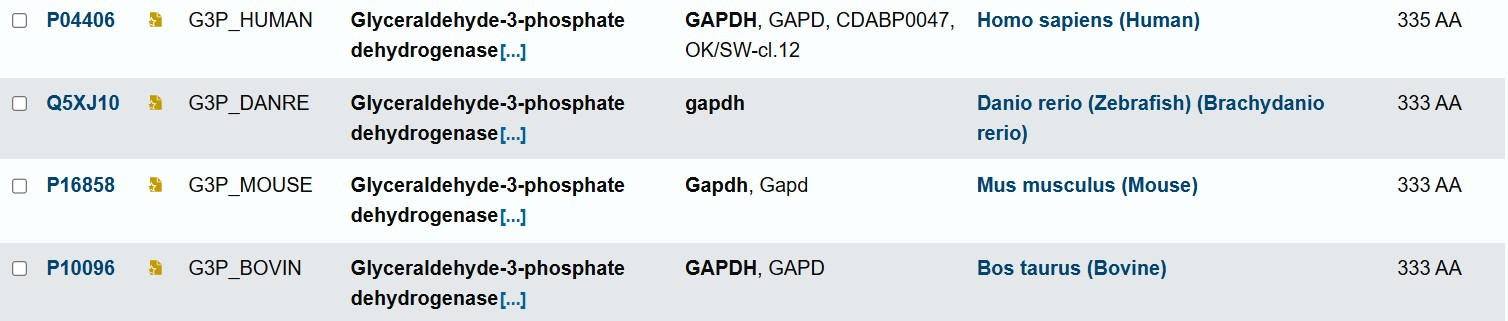

Для проведения множественного выравнивания использовал сайт MUSCLE.

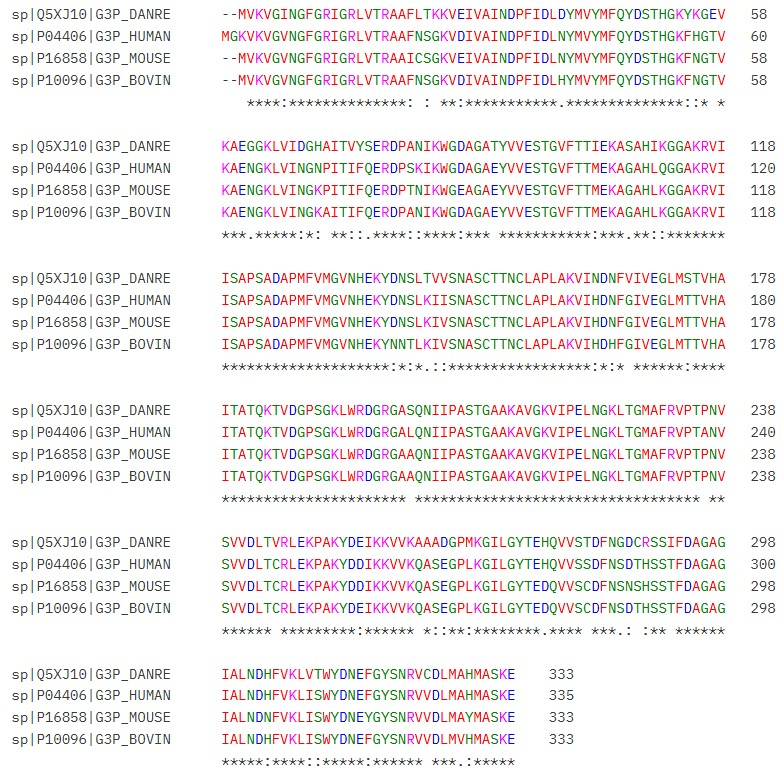

Получил Newick-формат: *(sp|Q5XJ10|G3P_DANRE:0.10811, sp|P04406|G3P_HUMAN:0.03003, (sp|P16858|G3P_MOUSE:0.03003, sp|P10096|G3P_BOVIN:0.02102):0.00150);* и дерево.

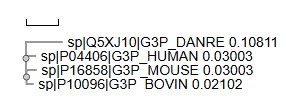

С помощью сайта ETEToolkit (https://etetoolkit.org/treeview/) построил дерево посимпатичнее.

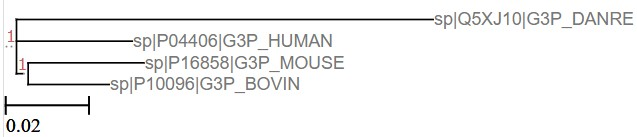

# Часть 2. MEGA и коронавирус

Внутри программы MEGA произвел множественное выравнивание и построил филогенетическое дерево для российских штаммов коронавируса.

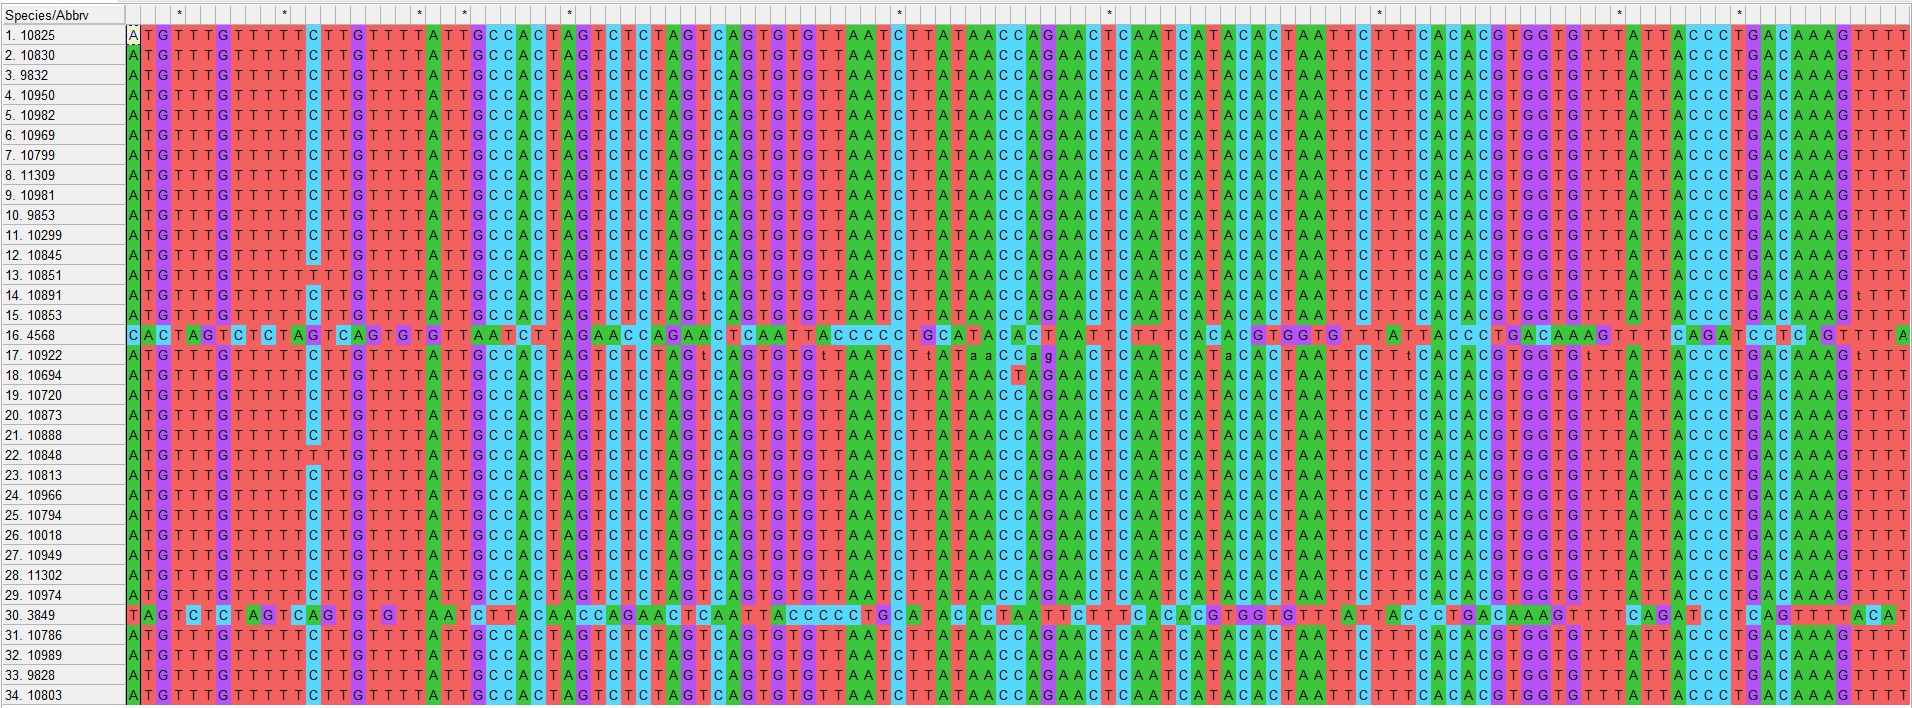

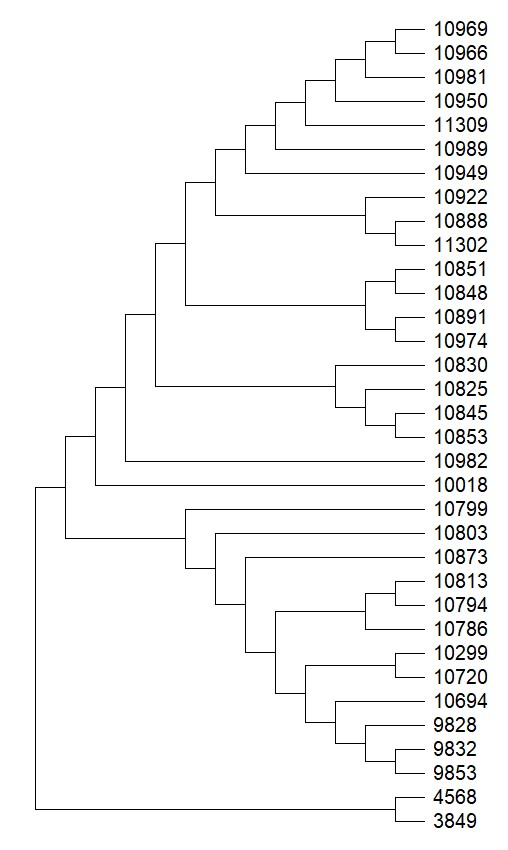

На дереве видно эволюционное развитие вируса: 3849 и 4568 - раннее ответвление; можно наблюдать более поздние разделения на современные (на момент сбора данных) мутации.

Далее я взял 3 spike белка коронавируса из Южной Кореи и добавил их к датасету. Выровнял и построил новое дерево.

Ссылки на взятые белки:

1) https://www.ncbi.nlm.nih.gov/protein/QIH45093.1

2) https://www.ncbi.nlm.nih.gov/protein/QIH45073.1

3) https://www.ncbi.nlm.nih.gov/protein/QIH45083.1

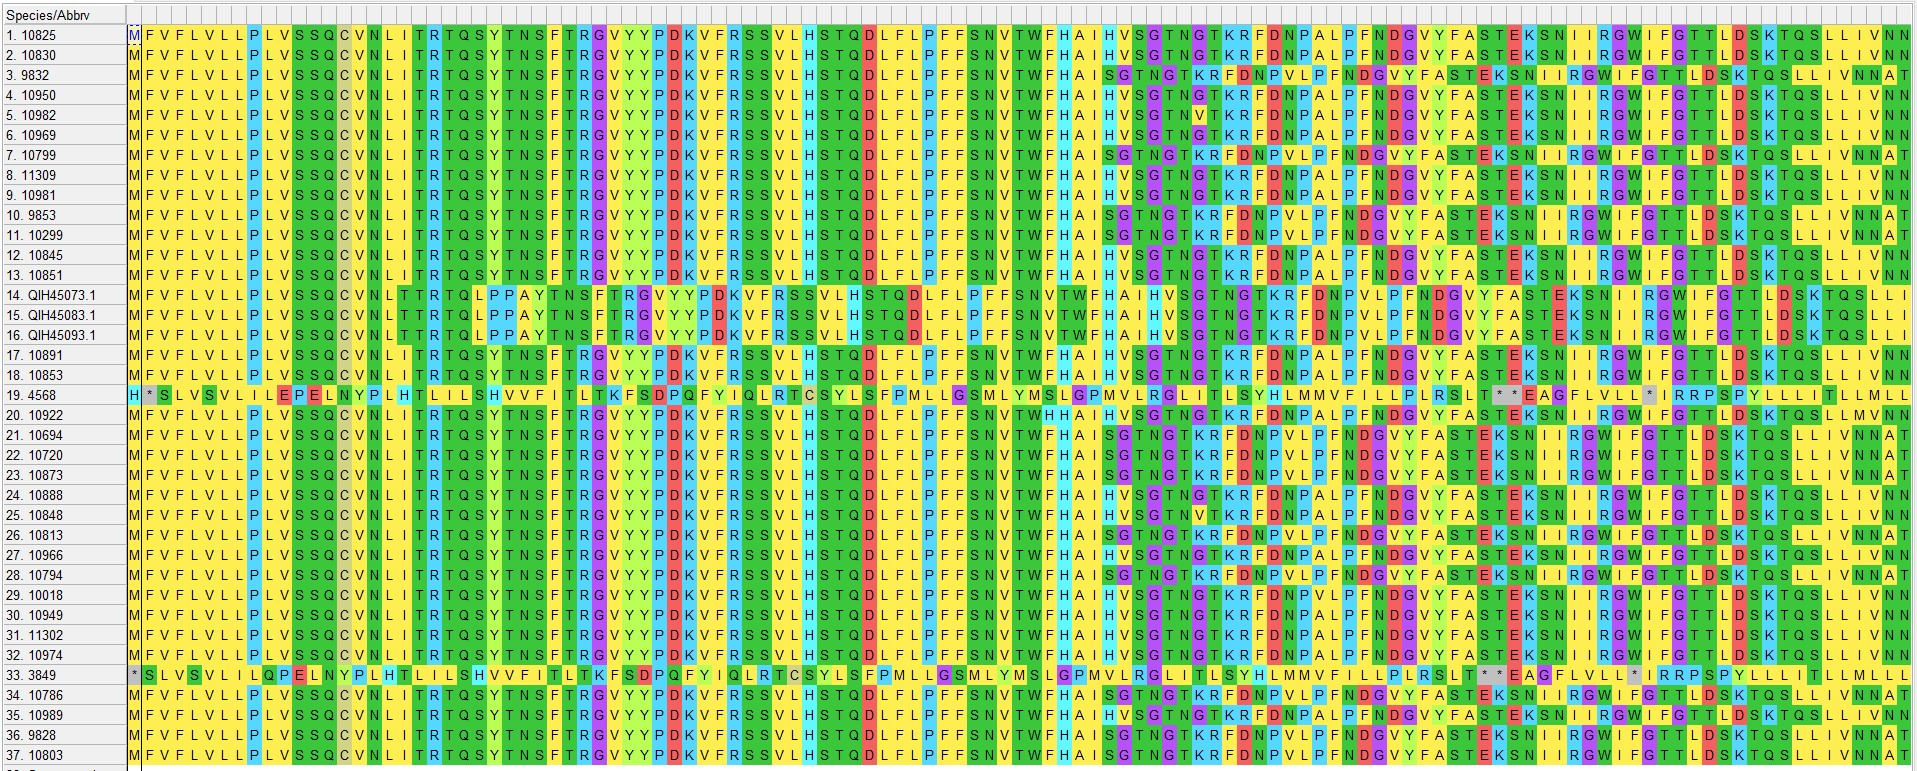

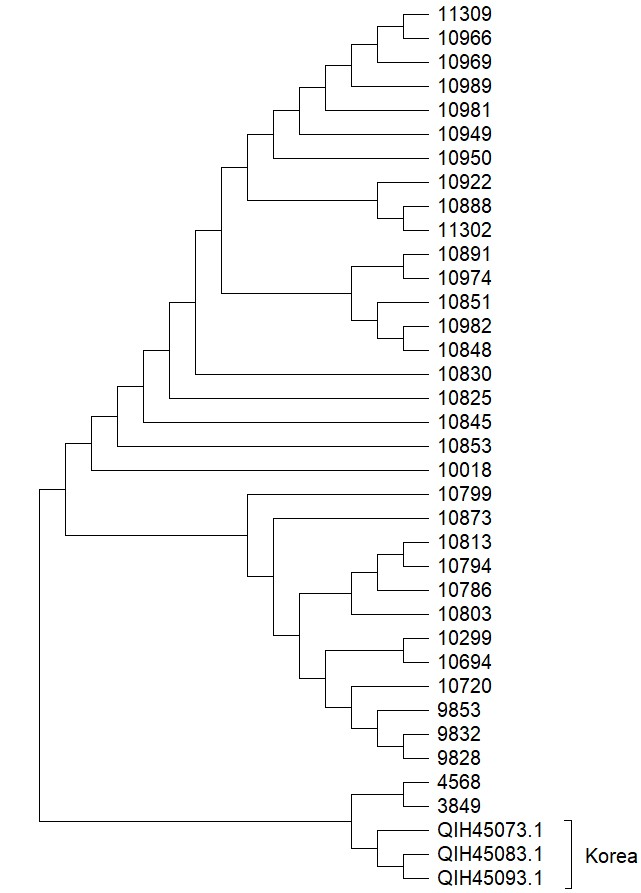

Можно видеть, что корейские штаммы значительно отдалены от "поздних" российских вирусов (которые уже какое-то время мутировали внутри России), но довольно близки к раннему ответвлению (4568 и 3849). У всех вирусов был общий предок.

# Часть 3. BLAST

По данному в задании участку последовательности EGMQCSCGIDYYTPHEETNNESFVIYMFVVHFIIPLIVIFFCYGQLVFTVKEAAAQQQES находим в базе данных nr соответствующий ей белок.

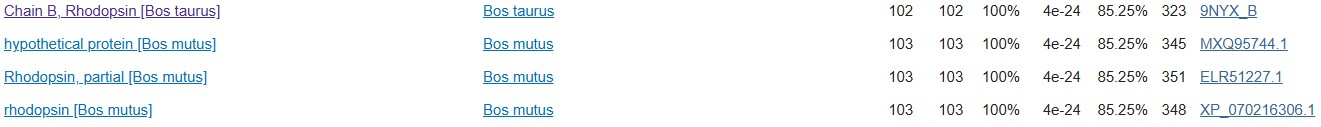

Как видно, это белок родопсин. Теперь попытаемся найти ортолог данного гена у человека. В этой задаче лучше использовать blastp, так как мы сравниваем белковые последовательности, а в процессе эволюции аминокислотная последовательность белка является более консервативной, чем последовательность ДНК. В качестве базы данных возьмем refseq_protein, так как она исключает дублирование и ошибки аннотации, которые могут встретиться в nr.

Нашелся единственный белок с названием родопсин у человека.

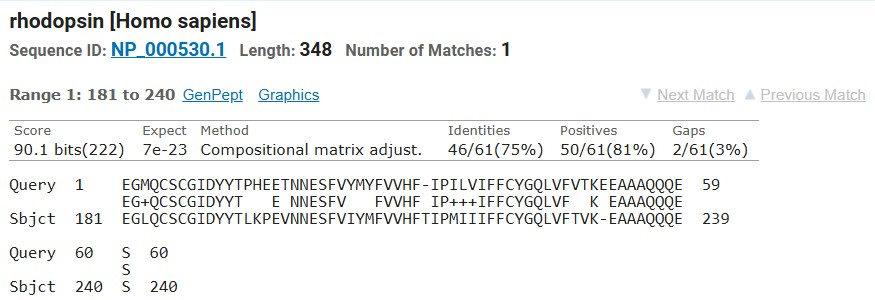

Нашел этот белок на UniProt, откуда достал информацию про обусловленный белком дефект зрения (проблемы с ночным зрением / ночная слепота).

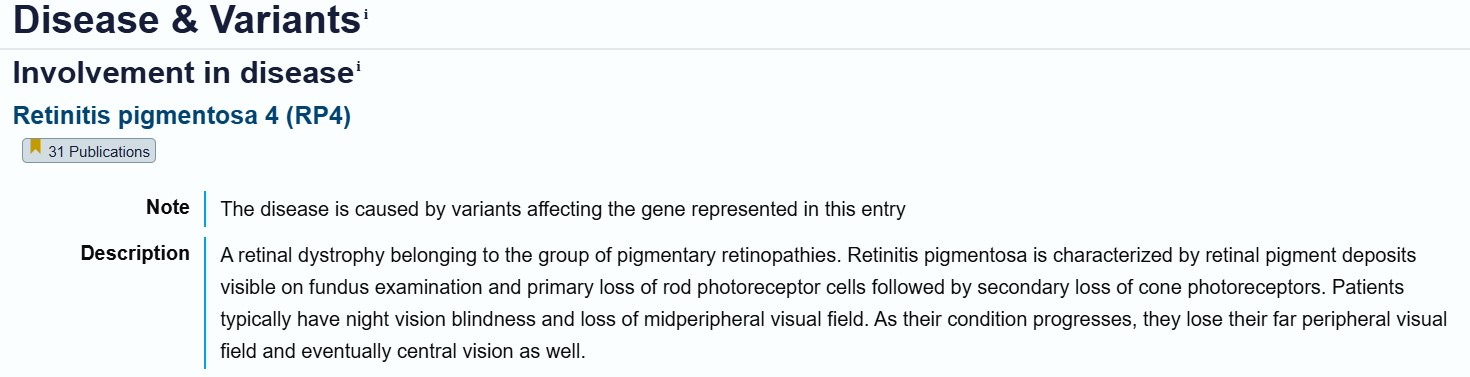

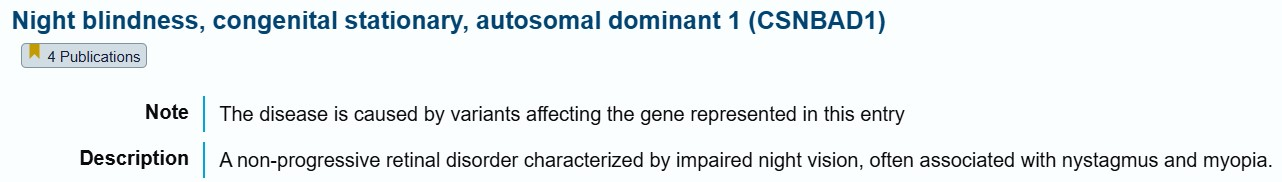

- Скачал транскриптом Photinus pyralis (FASTA) и белок люциферазы Luciola cruciata (UniProt).

- Перевел транскрипты в белки

TransDecoder.LongOrfs: TransDecoder.LongOrfs -t transcriptome.fasta

- Создал BLAST-базу

makeblastdb: makeblastdb -in transcriptome.fasta.transdecoder.pep -dbtype prot -out luciferase_db

- Нашел гомологи

blastp: blastp -query query.fasta -db luciferase_db -out results.txt -outfmt 6 -num_alignments 10

- Отобрал 10 лучших хитов

- Сохранил в FASTA

seqtk: seqtk subseq transcriptome.fasta.transdecoder.pep ids.txt > top10_candidates.fasta